In [1]:
import pandas as pd
df = pd.read_csv("housing.csv")
print(df.head())

# Central Tendency
print("Mean:\n", df.mean(numeric_only=True))
print("Median:\n", df.median(numeric_only=True))
print("Mode:\n", df.mode().iloc[0])

# Dispersion
print("Range:\n", df.max(numeric_only=True) - df.min(numeric_only=True))
print("Variance:\n", df.var(numeric_only=True))
print("Standard Deviation:\n", df.std(numeric_only=True))
print("IQR:\n", df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True))

# Shape

print("Skewness:\n", df.skew(numeric_only=True))
print("Kurtosis:\n", df.kurt(numeric_only=True))

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
Mean:
 price        4.766729e+06
area         5.150541e+03
bedrooms     2.965138e+00
bathrooms    1

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


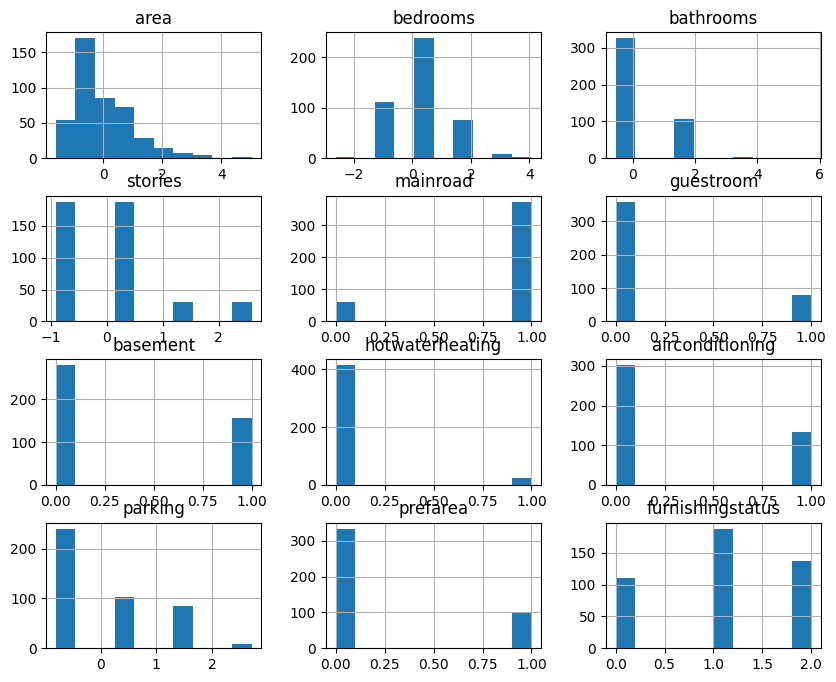

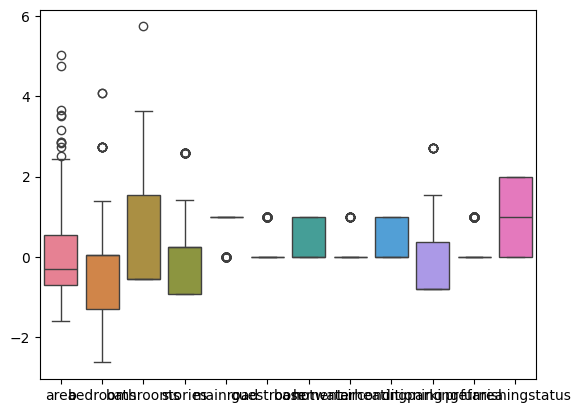

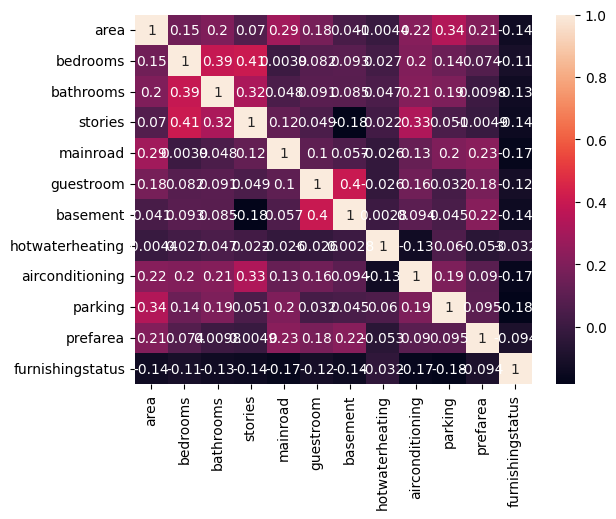

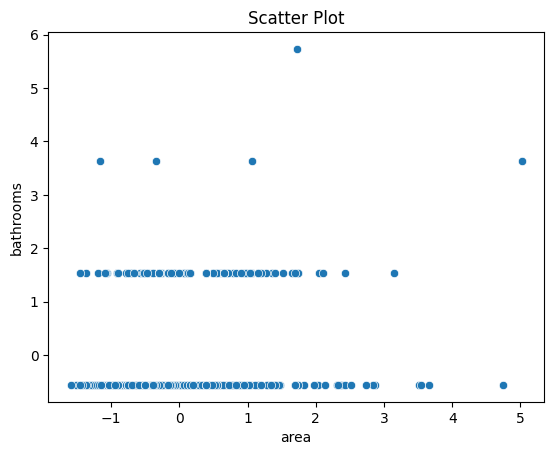

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
# Handle missing values
print(df.isnull().sum())
df = df.fillna(df.mean(numeric_only=True))

# Handle Label Encoding (Manually,if needed)
for col in [
'mainroad',
'guestroom',
'basement',
'hotwaterheating',
'airconditioning',
'prefarea',
'furnishingstatus'
]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
# -------------------------------
# SPLITTING (Assuming last column is target)
# -------------------------------
X = df.drop("price",axis=1)   # features
y = df["price"]  # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# DO EITHER NORMALIZATION OR STANDARDIZATION (ONLY ON TRAIN)
# -------------------------------
# NORMALIZATION (ONLY on TRAIN)
# -------------------------------
cat_cols = [
'mainroad',
'guestroom',
'basement',
'hotwaterheating',
'airconditioning',
'prefarea',
'furnishingstatus'
] # categorical columns
num_cols = X_train.select_dtypes(include='number').columns.difference(cat_cols)  # numeric cols

#minmax = MinMaxScaler()
#X_train[num_cols] = minmax.fit_transform(X_train[num_cols])
#X_test[num_cols] = minmax.transform(X_test[num_cols])

# -------------------------------
# STANDARDIZATION (ONLY on TRAIN)
# -------------------------------
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 5. Handle imbalance (only on training data ⚠️)

#smote = SMOTE()
#X_train, y_train = smote.fit_resample(X_train, y_train)
# -------------------------------
# VISUALIZATION (use full dataset OR train set)
# -------------------------------

# Histogram
X_train.hist(figsize=(10,8))
plt.show()

# Boxplot
sns.boxplot(data=X_train)
plt.show()

# Heatmap
sns.heatmap(X_train.corr(numeric_only=True), annot=True)
plt.show()

# Scatter Plot
if len(num_cols) >= 2:
    sns.scatterplot(x=X_train[num_cols[0]], y=X_train[num_cols[1]])
    plt.xlabel(num_cols[0])
    plt.ylabel(num_cols[1])
    plt.title("Scatter Plot")
    plt.show()
else:
    print("Not enough numeric columns for scatter plot")


Covariance Matrix:
                area  bathrooms  bedrooms   parking   stories
area       1.002299   0.199666  0.155030  0.338193  0.070634
bathrooms  0.199666   1.002299  0.392347  0.194483  0.316531
bedrooms   0.155030   0.392347  1.002299  0.141796  0.406035
parking    0.338193   0.194483  0.141796  1.002299  0.050721
stories    0.070634   0.316531  0.406035  0.050721  1.002299

Correlation Matrix:
                area  bathrooms  bedrooms   parking   stories
area       1.000000   0.199208  0.154674  0.337417  0.070472
bathrooms  0.199208   1.000000  0.391447  0.194037  0.315805
bedrooms   0.154674   0.391447  1.000000  0.141470  0.405104
parking    0.337417   0.194037  0.141470  1.000000  0.050604
stories    0.070472   0.315805  0.405104  0.050604  1.000000


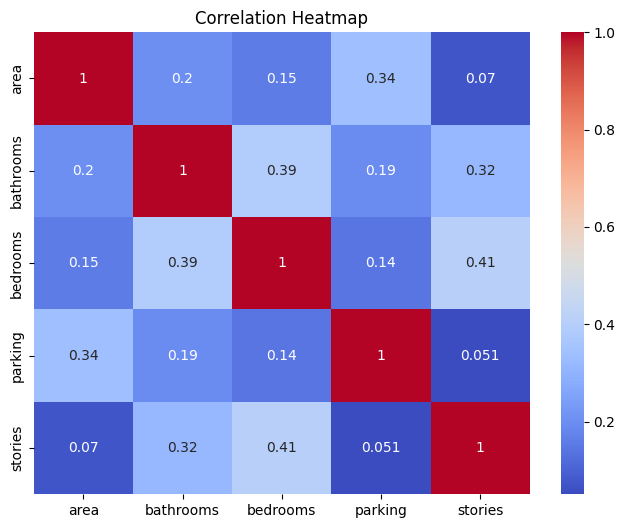

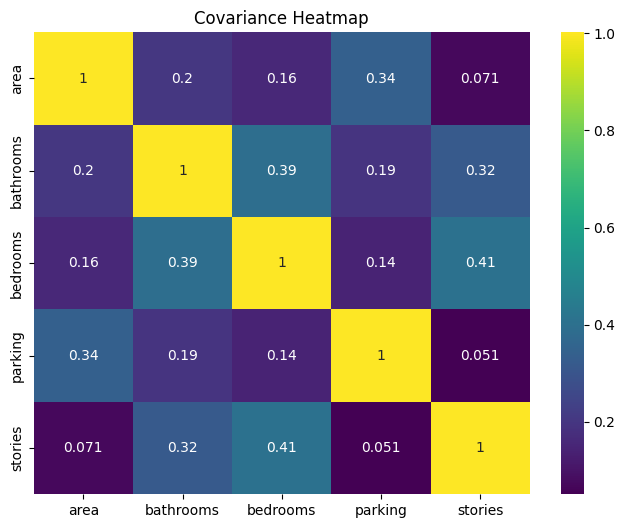

In [14]:
cov_matrix = X_train[num_cols].cov()
print("\nCovariance Matrix:\n", cov_matrix)

# -------------------------------
# CORRELATION
# -------------------------------
corr_matrix = X_train[num_cols].corr()
print("\nCorrelation Matrix:\n", corr_matrix)

# -------------------------------
# HEATMAP FOR CORRELATION
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# HEATMAP FOR COVARIANCE
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(cov_matrix, annot=True, cmap='viridis')
plt.title("Covariance Heatmap")
plt.show()

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_log = lr.predict(X_test)

print("\n--- Linear Regression ---")
print("MSE:", mean_squared_error(y_test, y_pred_log))
print("R2 Score:", r2_score(y_test, y_pred_log))



--- Linear Regression ---
MSE: 1771751116594.0388
R2 Score: 0.6494754192267796


In [18]:
import pandas as pd

new_house = pd.DataFrame([{
'area':7420,
'bedrooms':4,
'bathrooms':2,
'stories':3,
'mainroad':1,
'guestroom':0,
'basement':1,
'hotwaterheating':0,
'airconditioning':1,
'parking':2,
'prefarea':1,
'furnishingstatus':2
}])

new_house[num_cols] = scaler.transform(new_house[num_cols])

pred = lr.predict(new_house)

print("Predicted price:", pred[0])

Predicted price: 7976437.953722725
